# MATH 189 Project : Depression and Alcohol Use Among U.S. Adults
**Pre-COVID (2017 – March 2020) vs. During-COVID (August 2021 – August 2023)**

**Group members:** Indrani Vairagare, Elaine Gu, Raeed Bourai, Fahad Alkhazam

---

## 1. Introduction

### 1.1 Background and motivation
The COVID-19 pandemic produced large, simultaneous shocks to mental health and substance-use behaviors in the United States. Quarantine, social isolation, financial instability, and bereavement imposed psychological burdens at a population scale that few previous events had achieved. Two outcomes that drew particular concern were **depression** and **alcohol use**, both of which were tracked extensively in survey data and clinical reports throughout 2020–2023.

It is well-documented that alcohol use and depression are linked. The American Addiction Centers describes their relationship as **bidirectional**: depressive symptoms can drive drinking as a coping mechanism, and heavy drinking can in turn worsen depressive symptoms, producing a self-reinforcing cycle [1]. National survey work during the pandemic by Capasso et al. (2021) further documented that respondents who reported higher depression during COVID also reported increased alcohol consumption, consistent with alcohol use as a stress-coping behavior in the pandemic context [2].

### 1.2 Why this question is worth asking
Most prior analyses compare *marginal* rates of depression and drinking between periods (i.e., "did depression rise?", "did drinking rise?"). Fewer analyses ask whether the **underlying relationship** between depression and alcohol use changed. That is, whether the slope of alcohol use on depression strengthened during COVID, and whether any such strengthening was uneven across demographic subgroups. Quantifying this has direct implications for targeting mental-health and substance-use interventions in future public-health crises.

### 1.3 Research question
*What is the relationship between levels of depression and frequency of alcohol use among U.S. adults in the pre-COVID period (2017 – March 2020) compared to the during-COVID period (August 2021 – August 2023)?*

### 1.4 Hypothesis
We hypothesize that during the COVID period, adults in the U.S. with higher depression severity (as measured by the PHQ-9) reported higher frequency of alcohol use than would be predicted from the pre-COVID relationship. We further hypothesize that pandemic-era stressors strengthened the depression–alcohol relationship, with the effect potentially amplified in younger adults and those living without a partner.

### 1.5 Data sources and approach
We use three components from the CDC's National Health and Nutrition Examination Survey (NHANES) for each of two cycles:

| Component | Variable name(s) | Pre-COVID file | During-COVID file |
|-----------|------------------|----------------|-------------------|
| Depression (PHQ-9 questionnaire) | `DPQ010`–`DPQ090` | `P_DPQ.XPT`  | `DPQ_L.XPT`  |
| Alcohol use questionnaire        | `ALQ111`, `ALQ121`, `ALQ130`, `ALQ142` | `P_ALQ.XPT`  | `ALQ_L.XPT`  |
| Demographics                     | age, sex, race, income, marital status | `P_DEMO.XPT` | `DEMO_L.XPT` |

The pre-COVID files use the `P_` prefix (the CDC's combined 2017–March 2020 pre-pandemic release), and the during-COVID files use the `_L` suffix (August 2021–August 2023). All data are publicly available from the NHANES website (<https://wwwn.cdc.gov/nchs/nhanes/>).

This notebook handles the **data preparation and exploratory data analysis** for our project: loading raw `.XPT` files, cleaning each component, constructing analytic variables, stacking the two cycles into a single long-format dataframe with a `cycle` indicator, and exploring distributions, group differences, and bivariate patterns. Statistical modeling (multiple regression, General Linear Hypothesis F-tests, logistic regression) is handled in a separate analysis notebook.

---

### References
- [1] American Addiction Centers. *Alcohol & Depression.* <https://americanaddictioncenters.org/alcohol/risks-effects-dangers/depression>
- [2] Capasso, A., Jones, A. M., Ali, S. H., Foreman, J., Tozan, Y., & DiClemente, R. J. (2021). Increased alcohol use during the COVID-19 pandemic. <https://pmc.ncbi.nlm.nih.gov/articles/PMC8509511/>


## 2. Data Presentation

This section loads the raw NHANES `.XPT` files, cleans each component (depression, alcohol, demographics), and assembles a single analytic dataset that stacks the two cycles. Each respondent appears exactly once. NHANES does *not* follow the same individuals across cycles, so the two cycles are treated as independent cross-sectional samples and combined with a binary `cycle` indicator.


### 2.1 Imports and configuration

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Path to the folder holding the six NHANES .XPT files
DATA_DIR = './data'


### 2.2 Load raw NHANES files

We load all six files at once and print their shapes. Each questionnaire file contains a `SEQN` (respondent ID) plus its respective set of survey items. Demographics files are much larger because they include every respondent in the cycle, while the questionnaire files only include those who completed the section.


In [2]:
def load_xpt(name):
    """Load a NHANES .XPT file into a DataFrame and standardize SEQN as int."""
    df = pd.read_sas(os.path.join(DATA_DIR, name))
    df['SEQN'] = df['SEQN'].astype(int)
    return df

# Pre-COVID (2017 – March 2020 pre-pandemic release, "P_" prefix)
pre_dpq  = load_xpt('P_DPQ.XPT')
pre_alq  = load_xpt('P_ALQ.XPT')
pre_demo = load_xpt('P_DEMO.XPT')

# During-COVID (August 2021 – August 2023, "_L" suffix)
post_dpq  = load_xpt('DPQ_L.XPT')
post_alq  = load_xpt('ALQ_L.XPT')
post_demo = load_xpt('DEMO_L.XPT')

shapes = pd.DataFrame(
    [(name, df.shape[0], df.shape[1]) for name, df in [
        ('pre_dpq',  pre_dpq),  ('pre_alq',  pre_alq),  ('pre_demo',  pre_demo),
        ('post_dpq', post_dpq), ('post_alq', post_alq), ('post_demo', post_demo),
    ]],
    columns=['file', 'n_rows', 'n_cols'],
)
shapes


,file,n_rows,n_cols
0,pre_dpq,8965,11
1,pre_alq,8965,10
2,pre_demo,15560,29
3,post_dpq,6337,11
4,post_alq,6337,9
5,post_demo,11933,27


### 2.3 Clean the depression (PHQ-9) data

The PHQ-9 is a validated 9-item depression screener. Each of items `DPQ010`–`DPQ090` is scored 0 ("not at all") to 3 ("nearly every day"). Item `DPQ100` is a follow-up question on functional impairment and is *not* part of the total score.

In NHANES, responses of `7` (refused) and `9` (don't know) are recoded to `NaN`. We require all nine items to be present to compute a valid `PHQ9_Total` (range 0–27), and then apply the standard PHQ-9 severity bands.


In [3]:
PHQ_ITEMS = [f'DPQ0{i}0' for i in range(1, 10)]   # DPQ010 ... DPQ090

def clean_phq9(df):
    df = df.copy()
    # Recode special values to NaN
    for col in PHQ_ITEMS:
        df[col] = df[col].replace({7: np.nan, 9: np.nan})
    # Total score requires all nine items to be non-missing
    df['PHQ9_Total'] = df[PHQ_ITEMS].sum(axis=1, min_count=9)
    # Standard PHQ-9 severity bands
    bins   = [-0.1, 4, 9, 14, 19, 27]
    labels = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']
    df['Depression_Severity'] = pd.cut(df['PHQ9_Total'], bins=bins, labels=labels)
    return df[['SEQN', 'PHQ9_Total', 'Depression_Severity']]

pre_dpq_c  = clean_phq9(pre_dpq)
post_dpq_c = clean_phq9(post_dpq)

print('Pre-COVID  valid PHQ-9 totals:', pre_dpq_c['PHQ9_Total'].notna().sum())
print('Post-COVID valid PHQ-9 totals:', post_dpq_c['PHQ9_Total'].notna().sum())
pre_dpq_c.head()


Pre-COVID  valid PHQ-9 totals: 8276
Post-COVID valid PHQ-9 totals: 5455


,SEQN,PHQ9_Total,Depression_Severity
0,109266,0.000,Minimal
1,109271,5.000,Mild
2,109273,15.000,Moderately Severe
3,109274,0.000,Minimal
4,109282,5.000,Mild


### 2.4 Clean the alcohol use data

From the ALQ questionnaire we construct three outcome variables:

- **`Drink_Days_Year`** : estimated drinking days per year, mapped from the categorical `ALQ121` ("During the past 12 months, how often did you drink any type of alcoholic beverage?"). The mapping uses the midpoint of each NHANES response category.
- **`Avg_Drinks_Per_Day`** : `ALQ130` (average drinks per drinking day), top-coded at 25 to limit influence of extreme self-reports.
- **`Binge_Any`** : binary indicator that the respondent reported any binge-drinking days in the past 12 months (from `ALQ142`). Lifetime non-drinkers (`ALQ111 == 2`) are coded as `0`.

NHANES special codes are recoded to `NaN`: `7`/`9` for single-digit items, `77`/`99` for two-digit items, and `777`/`999` for three-digit items, in line with the CDC codebook.


In [4]:
# Map ALQ121 response categories to estimated drinking days per year
ALQ121_TO_DAYS = {
    0:   0,     # Never in the last year
    1: 365,     # Every day
    2: 330,     # Nearly every day
    3: 182,     # 3 to 4 times a week
    4: 104,     # 2 times a week
    5:  52,     # Once a week
    6:  30,     # 2 to 3 times a month
    7:  12,     # Once a month
    8:   9,     # 7 to 11 times in the last year
    9:   4.5,   # 3 to 6 times in the last year
    10:  1.5,   # 1 to 2 times in the last year
}

def clean_alcohol(df):
    df = df.copy()
    # Replace refused / don't-know codes with NaN across alcohol items
    for col, missing in [
        ('ALQ111', [7, 9]), ('ALQ121', [77, 99]),
        ('ALQ130', [777, 999]), ('ALQ142', [77, 99]),
        ('ALQ151', [7, 9]), ('ALQ170', [777, 999]),
    ]:
        if col in df.columns:
            df[col] = df[col].replace({m: np.nan for m in missing})

    # Construct analytic variables
    df['Drink_Days_Year']   = df['ALQ121'].map(ALQ121_TO_DAYS)
    df['Avg_Drinks_Per_Day'] = df['ALQ130'].clip(upper=25)
    df['Binge_Any']         = (df['ALQ142'].fillna(0) > 0).astype(int)
    df.loc[df['ALQ111'] == 2, 'Binge_Any'] = 0     # never-drinkers

    return df[['SEQN', 'ALQ111', 'Drink_Days_Year',
               'Avg_Drinks_Per_Day', 'Binge_Any']]

pre_alq_c  = clean_alcohol(pre_alq)
post_alq_c = clean_alcohol(post_alq)

print('Pre-COVID  valid drinking-days values:', pre_alq_c['Drink_Days_Year'].notna().sum())
print('Post-COVID valid drinking-days values:', post_alq_c['Drink_Days_Year'].notna().sum())
pre_alq_c.head()


Pre-COVID  valid drinking-days values: 5861
Post-COVID valid drinking-days values: 4081


,SEQN,ALQ111,Drink_Days_Year,Avg_Drinks_Per_Day,Binge_Any
0,109266,1.000,1.500,1.000,1
1,109271,1.000,NaN,NaN,0
2,109273,1.000,NaN,NaN,0
3,109274,1.000,104.000,2.000,1
4,109282,1.000,NaN,NaN,0


### 2.5 Clean the demographic data

We retain the variables we'll use as descriptors and (in the analysis notebook) regression controls: age, sex, race/ethnicity, family income-to-poverty ratio (PIR), marital status, and education. Survey weights and design variables are renamed to a common set of column names so the two cycles can be stacked.


In [5]:
RACE_MAP = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other/Multi',
}
SEX_MAP     = {1: 'Male', 2: 'Female'}
MARITAL_MAP = {1: 'Married/Partner',
               2: 'Widowed/Divorced/Separated',
               3: 'Never Married'}

def clean_demographics(df, weight_col_int, weight_col_mec):
    df = df.copy()
    return pd.DataFrame({
        'SEQN':     df['SEQN'],
        'Age':      df['RIDAGEYR'],
        'Sex':      df['RIAGENDR'].map(SEX_MAP),
        'Race':     df['RIDRETH3'].map(RACE_MAP),
        'PIR':      df['INDFMPIR'],
        'Marital':  df['DMDMARTZ'].replace({77: np.nan, 99: np.nan}).map(MARITAL_MAP),
        'Edu':      df['DMDEDUC2'].replace({7: np.nan, 9: np.nan}),
        'WT_INT':   df[weight_col_int],
        'WT_MEC':   df[weight_col_mec],
        'SDMVPSU':  df['SDMVPSU'],
        'SDMVSTRA': df['SDMVSTRA'],
    })

pre_demo_c  = clean_demographics(pre_demo,  'WTINTPRP', 'WTMECPRP')
post_demo_c = clean_demographics(post_demo, 'WTINT2YR', 'WTMEC2YR')
print(f'Pre-COVID  DEMO rows: {len(pre_demo_c):,}')
print(f'Post-COVID DEMO rows: {len(post_demo_c):,}')
pre_demo_c.head()


Pre-COVID  DEMO rows: 15,560
Post-COVID DEMO rows: 11,933


,SEQN,Age,Sex,Race,PIR,Marital,Edu,WT_INT,WT_MEC,SDMVPSU,SDMVSTRA
0,109263,2.000,Male,Non-Hispanic Asian,4.660,NaN,NaN,"7,891.762","8,951.816",3.000,156.000
1,109264,13.000,Female,Mexican American,0.830,NaN,NaN,"11,689.747","12,271.157",1.000,155.000
2,109265,2.000,Male,Non-Hispanic White,3.060,NaN,NaN,"16,273.826","16,658.764",1.000,157.000
3,109266,29.000,Female,Non-Hispanic Asian,5.000,Never Married,5.000,"7,825.646","8,154.968",2.000,168.000
4,109267,21.000,Female,Other Hispanic,5.000,Never Married,4.000,"26,379.992",0.000,1.000,156.000


### 2.6 Merge within each cycle and stack the two cycles

Within each cycle we merge the three cleaned components on `SEQN`. The two cycles are then stacked vertically into a single long-format dataframe with two cycle labels: `cycle == 0` for pre-COVID, `cycle == 1` for during-COVID. Each row is a unique respondent.

We restrict the analytic sample to adults (age ≥ 18) with non-missing PHQ-9 and demographic data.


In [6]:
def assemble_cycle(dpq, alq, demo, cycle_label, cycle_indicator):
    df = (dpq
          .merge(alq,  on='SEQN', how='inner')
          .merge(demo, on='SEQN', how='inner'))
    df['cycle']     = cycle_indicator         # 0 = pre-COVID, 1 = during-COVID
    df['cycle_lbl'] = cycle_label
    return df

pre_full  = assemble_cycle(pre_dpq_c,  pre_alq_c,  pre_demo_c,  'Pre-COVID',    0)
post_full = assemble_cycle(post_dpq_c, post_alq_c, post_demo_c, 'During-COVID', 1)

combined = pd.concat([pre_full, post_full], ignore_index=True)
print(f'Combined raw rows: {len(combined):,}')

# Restrict to adults with complete data on the variables we need
keep_cols = ['PHQ9_Total', 'Age', 'Sex', 'Race', 'PIR', 'Marital']
analytic = (combined
            .query('Age >= 18')
            .dropna(subset=keep_cols)
            .reset_index(drop=True))

print(f'Final analytic sample size: {len(analytic):,}')
print()
print('Sample sizes by cycle:')
print(analytic['cycle_lbl'].value_counts().to_string())

analytic.head()


Combined raw rows: 15,302
Final analytic sample size: 11,433

Sample sizes by cycle:
cycle_lbl
Pre-COVID       6851
During-COVID    4582


,SEQN,PHQ9_Total,Depression_Severity,ALQ111,Drink_Days_Year,Avg_Drinks_Per_Day,Binge_Any,Age,Sex,Race,PIR,Marital,Edu,WT_INT,WT_MEC,SDMVPSU,SDMVSTRA,cycle,cycle_lbl
0,109266,0.000,Minimal,1.000,1.500,1.000,1,29.000,Female,Non-Hispanic Asian,5.000,Never Married,5.000,"7,825.646","8,154.968",2.000,168.000,0,Pre-COVID
1,109273,15.000,Moderately Severe,1.000,NaN,NaN,0,36.000,Male,Non-Hispanic White,0.830,Never Married,4.000,"20,171.848","22,163.597",1.000,155.000,0,Pre-COVID
2,109274,0.000,Minimal,1.000,104.000,2.000,1,68.000,Male,Other/Multi,1.200,Never Married,4.000,"7,227.993","7,801.600",2.000,167.000,0,Pre-COVID
3,109282,5.000,Mild,1.000,NaN,NaN,0,76.000,Male,Non-Hispanic White,3.610,Married/Partner,5.000,"28,363.015","31,816.346",2.000,164.000,0,Pre-COVID
4,109290,2.000,Minimal,1.000,NaN,NaN,0,68.000,Female,Non-Hispanic Black,5.000,Widowed/Divorced/Separated,5.000,"3,967.693","4,099.842",1.000,171.000,0,Pre-COVID


## 3. Exploratory Data Analysis

The goal of this section is to *describe* our analytic sample and surface the patterns that will motivate the modeling work in the analysis notebook. We cover:

1. **Sample composition**: sizes, demographic breakdowns, missingness audit.
2. **Univariate distributions**: depression scores, alcohol-use measures, key demographic variables, by cycle.
3. **Categorical patterns**: depression severity bands and alcohol-related rates.
4. **Bivariate relationships**: alcohol use as a function of depression severity, with subgroup overlays.
5. **Correlation structure**: between the main numeric variables.

Throughout, we present pre-COVID and during-COVID side by side so that any cycle-level shifts are immediately visible.


### 3.1 Sample composition and descriptive statistics

We first summarize the analytic sample with sample sizes, means, medians, and key proportions for each cycle. This single table is the single most important descriptive output in the project: it shows what populations we are actually comparing.


In [7]:
desc = analytic.groupby('cycle_lbl').agg(
    n               =('SEQN', 'count'),
    age_mean        =('Age', 'mean'),
    age_sd          =('Age', 'std'),
    pct_female      =('Sex', lambda s: (s == 'Female').mean() * 100),
    phq9_mean       =('PHQ9_Total', 'mean'),
    phq9_sd         =('PHQ9_Total', 'std'),
    phq9_median     =('PHQ9_Total', 'median'),
    drinkdays_mean  =('Drink_Days_Year', 'mean'),
    drinkdays_median=('Drink_Days_Year', 'median'),
    binge_pct       =('Binge_Any', lambda s: s.mean() * 100),
).round(2)

desc.T   # transpose for easier side-by-side reading


cycle_lbl,During-COVID,Pre-COVID
n,"4,582.000","6,851.000"
age_mean,53.760,50.760
age_sd,16.920,17.390
pct_female,54.910,51.250
phq9_mean,4.100,3.290
phq9_sd,4.740,4.250
phq9_median,2.000,2.000
drinkdays_mean,87.020,72.670
drinkdays_median,30.000,30.000
binge_pct,75.620,71.360


#### Demographic breakdowns by cycle

In [8]:
for col in ['Sex', 'Race', 'Marital']:
    print(f'\n=== {col} (% within cycle) ===')
    tab = (analytic.groupby('cycle_lbl')[col]
                   .value_counts(normalize=True)
                   .mul(100).round(1)
                   .unstack(col))
    print(tab.to_string())



=== Sex (% within cycle) ===
Sex           Female   Male
cycle_lbl                  
During-COVID  54.900 45.100
Pre-COVID     51.200 48.800

=== Race (% within cycle) ===
Race          Mexican American  Non-Hispanic Asian  Non-Hispanic Black  Non-Hispanic White  Other Hispanic  Other/Multi
cycle_lbl                                                                                                              
During-COVID             6.200               4.400              10.800              62.900           9.100        6.600
Pre-COVID               11.100              11.100              25.900              37.200           9.800        5.000

=== Marital (% within cycle) ===
Marital       Married/Partner  Never Married  Widowed/Divorced/Separated
cycle_lbl                                                               
During-COVID           54.300         20.500                      25.200
Pre-COVID              58.500         18.900                      22.600


### 3.2 Missingness audit

We check missingness on the variables that matter most for the analysis. `Drink_Days_Year` is expected to have more missingness because respondents who reported "never drank in the past 12 months" via `ALQ111` skip out of the frequency question.


In [9]:
miss = (analytic.groupby('cycle_lbl')[
            ['PHQ9_Total', 'Drink_Days_Year', 'Avg_Drinks_Per_Day',
             'Binge_Any', 'PIR', 'Marital']]
        .apply(lambda d: d.isna().mean() * 100)
        .round(1))
print('Percent missing by cycle:')
miss


Percent missing by cycle:


,PHQ9_Total,Drink_Days_Year,Avg_Drinks_Per_Day,Binge_Any,PIR,Marital
cycle_lbl,,,,,,
During-COVID,0.000,24.000,24.400,0.000,0.000,0.000
Pre-COVID,0.000,28.400,28.500,0.000,0.000,0.000


### 3.3 Distribution of depression (PHQ-9 total) by cycle

PHQ-9 is a heavily right-skewed measure, most respondents score in the minimal range (0–4). Comparing the right tail across cycles is more informative than comparing the means.


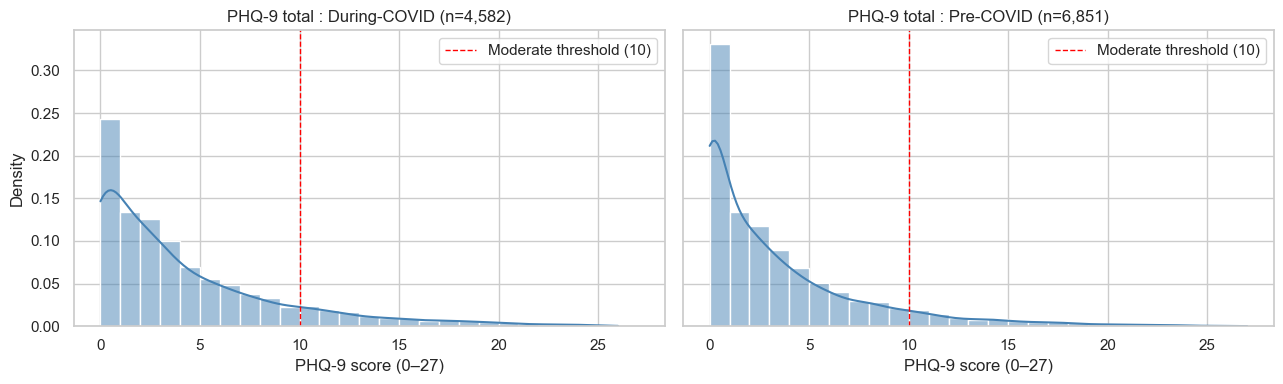

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (lbl, sub) in zip(axes, analytic.groupby('cycle_lbl')):
    sns.histplot(sub['PHQ9_Total'], bins=range(0, 28),
                 stat='density', kde=True, ax=ax, color='steelblue')
    ax.set_title(f'PHQ-9 total : {lbl} (n={len(sub):,})')
    ax.set_xlabel('PHQ-9 score (0–27)')
    ax.set_ylabel('Density')
    ax.axvline(10, color='red', linestyle='--', lw=1,
               label='Moderate threshold (10)')
    ax.legend()
plt.tight_layout()
plt.show()


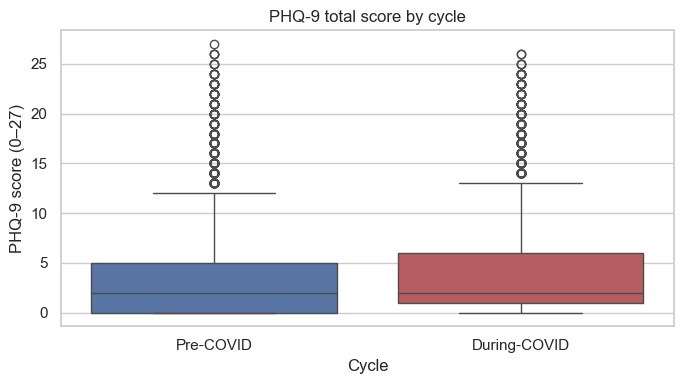

In [11]:
# Side-by-side boxplot of PHQ-9 totals by cycle
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=analytic, x='cycle_lbl', y='PHQ9_Total',
            ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('PHQ-9 total score by cycle')
ax.set_xlabel('Cycle')
ax.set_ylabel('PHQ-9 score (0–27)')
plt.tight_layout()
plt.show()


### 3.4 Depression severity categories by cycle

Collapsing PHQ-9 totals into the standard severity bands lets us read the cycle-level shift directly. We expect the bulk of respondents to fall in *Minimal* in both cycles; the question is whether the *Moderate*-and-higher categories grew during COVID.


In [12]:
sev_order = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']
sev_tab = (analytic
           .groupby('cycle_lbl')['Depression_Severity']
           .value_counts(normalize=True)
           .mul(100).round(1)
           .unstack('cycle_lbl')
           .reindex(sev_order))
print('Depression severity (% within cycle):')
print(sev_tab.to_string())


Depression severity (% within cycle):
cycle_lbl            During-COVID  Pre-COVID
Depression_Severity                         
Minimal                    67.200     73.900
Mild                       19.900     17.100
Moderate                    8.100      6.000
Moderately Severe           3.400      2.200
Severe                      1.400      0.900


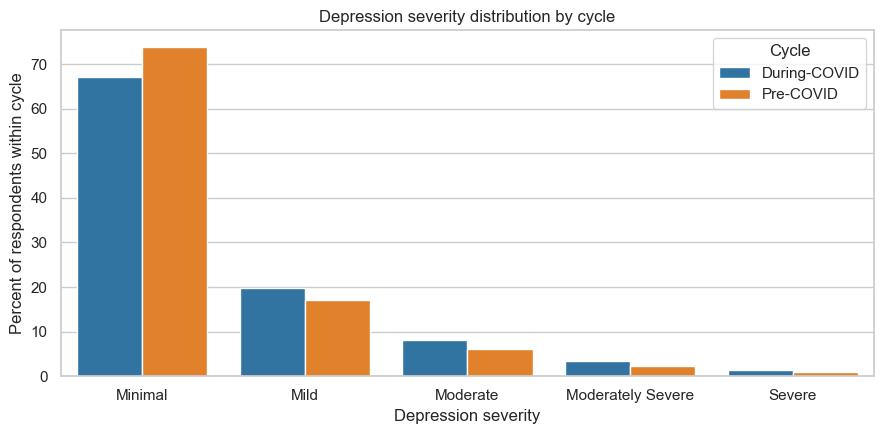

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sev_long = (analytic.dropna(subset=['Depression_Severity'])
                    .groupby('cycle_lbl')['Depression_Severity']
                    .value_counts(normalize=True).mul(100)
                    .rename('pct').reset_index())
sns.barplot(data=sev_long, x='Depression_Severity', y='pct',
            hue='cycle_lbl', order=sev_order, ax=ax)
ax.set_title('Depression severity distribution by cycle')
ax.set_xlabel('Depression severity')
ax.set_ylabel('Percent of respondents within cycle')
ax.legend(title='Cycle')
plt.tight_layout()
plt.show()


### 3.5 Distribution of alcohol use by cycle

We look at three alcohol measures:

- estimated drinking days per year (`Drink_Days_Year`), restricted to drinkers (>0) for the histograms so the zero spike doesn't dominate
- average drinks per drinking day (`Avg_Drinks_Per_Day`)
- binge-drinking rate (`Binge_Any`)


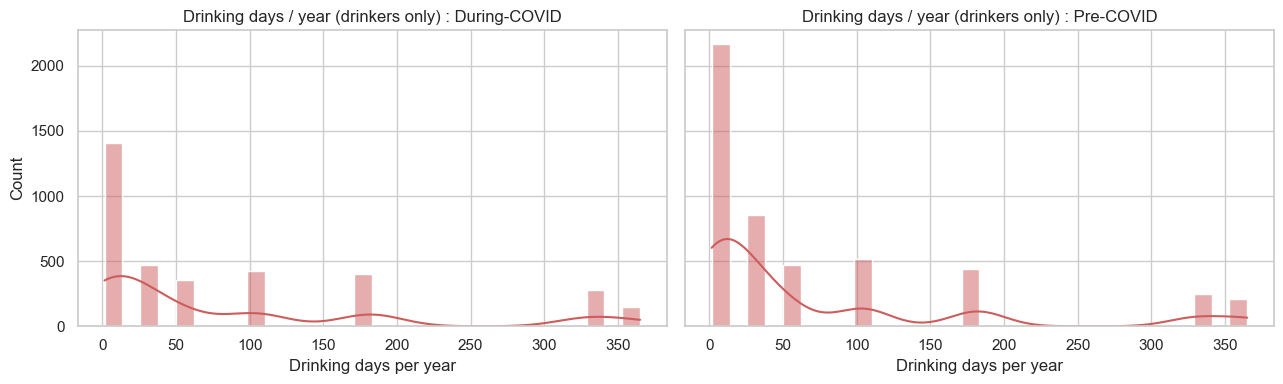

In [14]:
# Drinking days/year, drinkers only
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (lbl, sub) in zip(axes, analytic.groupby('cycle_lbl')):
    drinkers = sub[sub['Drink_Days_Year'] > 0]
    sns.histplot(drinkers['Drink_Days_Year'], bins=30,
                 kde=True, ax=ax, color='indianred')
    ax.set_title(f'Drinking days / year (drinkers only) : {lbl}')
    ax.set_xlabel('Drinking days per year')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


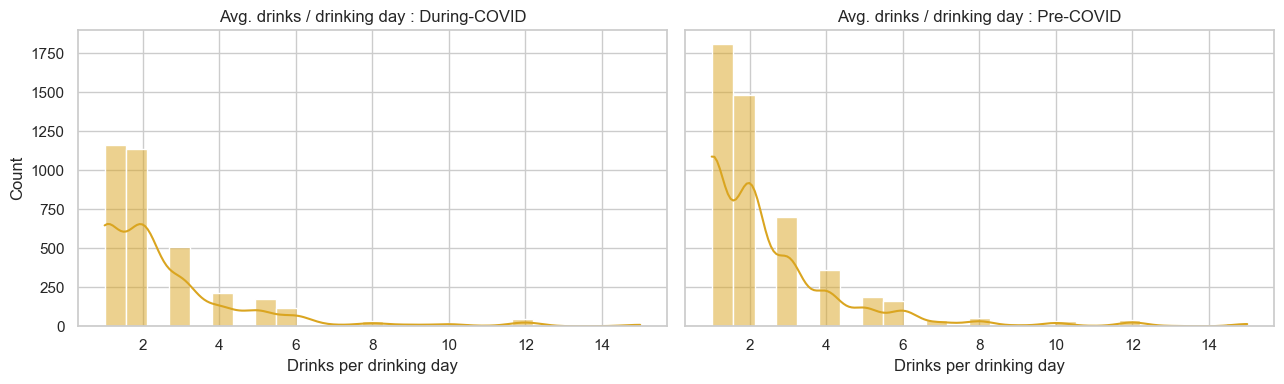

In [15]:
# Average drinks per drinking day
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (lbl, sub) in zip(axes, analytic.groupby('cycle_lbl')):
    sns.histplot(sub['Avg_Drinks_Per_Day'].dropna(), bins=25,
                 kde=True, ax=ax, color='goldenrod')
    ax.set_title(f'Avg. drinks / drinking day : {lbl}')
    ax.set_xlabel('Drinks per drinking day')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [16]:
# Binge drinking rate by cycle
binge_overall = (analytic.groupby('cycle_lbl')['Binge_Any']
                 .mean().mul(100).round(2)
                 .rename('Binge_Any_pct'))
print('Overall binge-drinking rate (%) by cycle:')
print(binge_overall.to_string())


Overall binge-drinking rate (%) by cycle:
cycle_lbl
During-COVID   75.620
Pre-COVID      71.360


### 3.6 Bivariate relationship: alcohol use × depression severity

This is the central descriptive view for our research question. If the depression–alcohol relationship strengthened during COVID, we expect the *gap* between the lowest and highest depression severity bands to be wider during-COVID than pre-COVID.


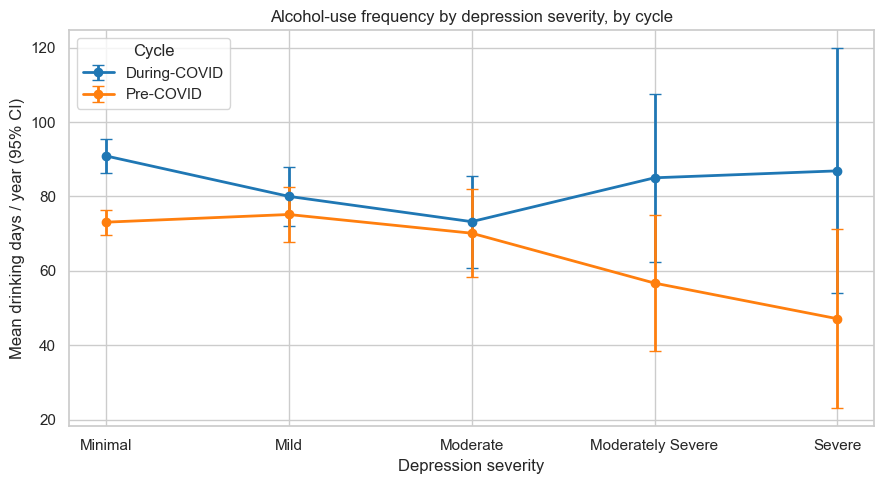

In [17]:
plot_df = (analytic
           .dropna(subset=['Depression_Severity', 'Drink_Days_Year'])
           .groupby(['cycle_lbl', 'Depression_Severity'])
           .agg(mean_days=('Drink_Days_Year', 'mean'),
                se_days  =('Drink_Days_Year',
                           lambda x: x.std() / np.sqrt(len(x))))
           .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, sub in plot_df.groupby('cycle_lbl'):
    ax.errorbar(sub['Depression_Severity'].astype(str), sub['mean_days'],
                yerr=1.96 * sub['se_days'], marker='o',
                capsize=4, label=lbl, lw=2)
ax.set_xlabel('Depression severity')
ax.set_ylabel('Mean drinking days / year (95% CI)')
ax.set_title('Alcohol-use frequency by depression severity, by cycle')
ax.legend(title='Cycle')
plt.tight_layout()
plt.show()


In [18]:
# Binge drinking rate by depression severity and cycle
binge_tab = (analytic.dropna(subset=['Depression_Severity'])
             .groupby(['cycle_lbl', 'Depression_Severity'])['Binge_Any']
             .mean().mul(100).round(1)
             .unstack('cycle_lbl')
             .reindex(sev_order))
print('Binge-drinking prevalence (%) by depression severity and cycle:')
print(binge_tab.to_string())


Binge-drinking prevalence (%) by depression severity and cycle:
cycle_lbl            During-COVID  Pre-COVID
Depression_Severity                         
Minimal                    75.500     71.600
Mild                       78.100     71.400
Moderate                   74.900     68.800
Moderately Severe          63.900     69.300
Severe                     76.900     74.200


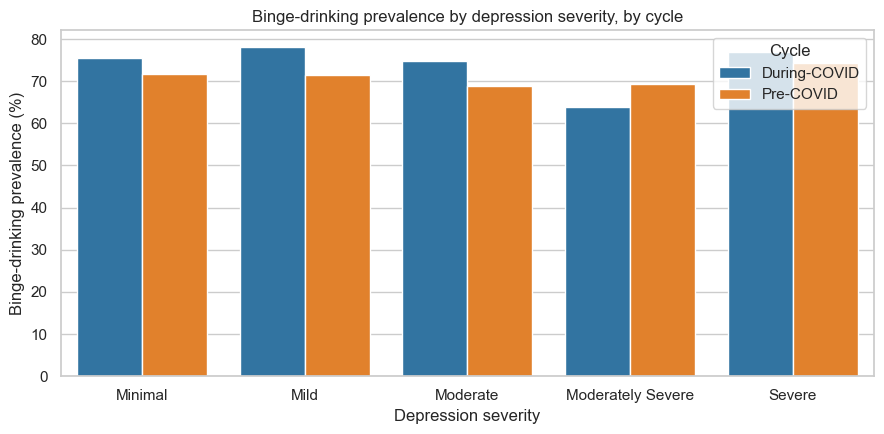

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
binge_long = (analytic.dropna(subset=['Depression_Severity'])
              .groupby(['cycle_lbl', 'Depression_Severity'])['Binge_Any']
              .mean().mul(100)
              .rename('binge_pct').reset_index())
sns.barplot(data=binge_long, x='Depression_Severity', y='binge_pct',
            hue='cycle_lbl', order=sev_order, ax=ax)
ax.set_title('Binge-drinking prevalence by depression severity, by cycle')
ax.set_xlabel('Depression severity')
ax.set_ylabel('Binge-drinking prevalence (%)')
ax.legend(title='Cycle')
plt.tight_layout()
plt.show()


### 3.7 Subgroup patterns: age and sex

The hypothesis suggests that the depression–alcohol shift, if present, may be uneven across demographic subgroups. We split the bivariate view by age group and by sex.


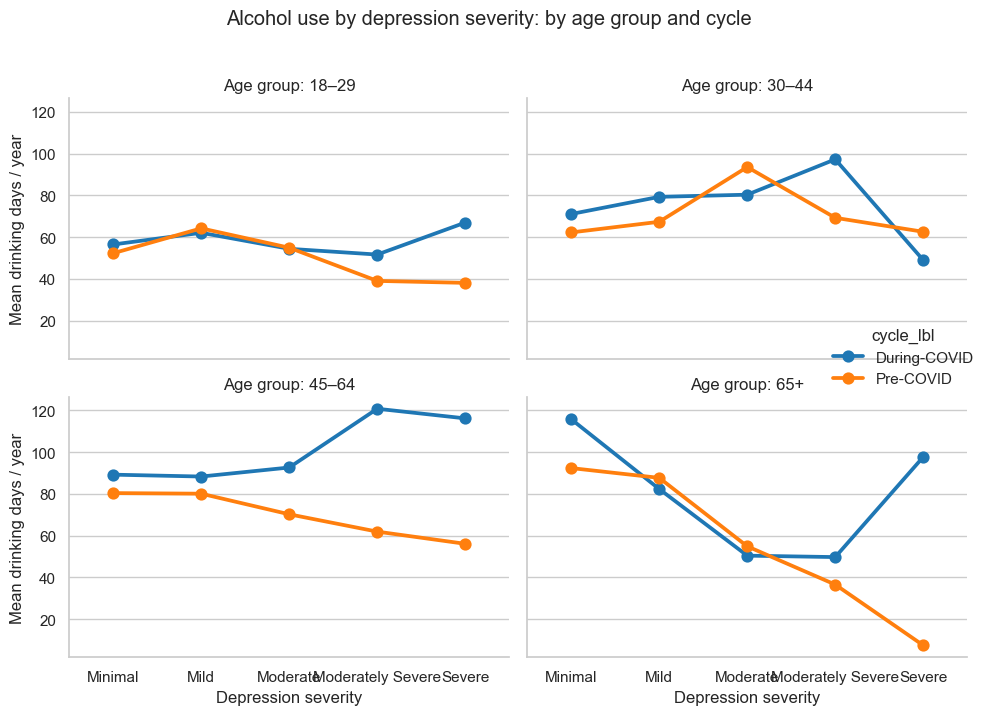

In [20]:
analytic['AgeGroup'] = pd.cut(
    analytic['Age'],
    bins=[17, 29, 44, 64, 120],
    labels=['18–29', '30–44', '45–64', '65+'],
)

age_plot = (analytic
            .dropna(subset=['Depression_Severity', 'Drink_Days_Year', 'AgeGroup'])
            .groupby(['cycle_lbl', 'AgeGroup', 'Depression_Severity'])
            ['Drink_Days_Year'].mean().reset_index())

g = sns.catplot(data=age_plot, x='Depression_Severity', y='Drink_Days_Year',
                hue='cycle_lbl', col='AgeGroup', kind='point',
                order=sev_order, col_wrap=2, height=3.5, aspect=1.2)
g.set_axis_labels('Depression severity', 'Mean drinking days / year')
g.set_titles('Age group: {col_name}')
g.fig.suptitle('Alcohol use by depression severity: by age group and cycle',
               y=1.02)
plt.tight_layout()
plt.show()


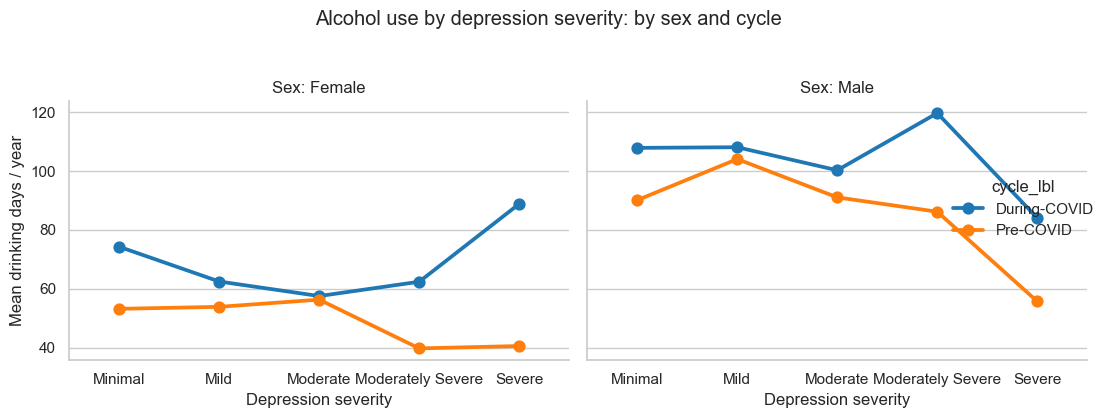

In [21]:
sex_plot = (analytic
            .dropna(subset=['Depression_Severity', 'Drink_Days_Year'])
            .groupby(['cycle_lbl', 'Sex', 'Depression_Severity'])
            ['Drink_Days_Year'].mean().reset_index())

g = sns.catplot(data=sex_plot, x='Depression_Severity', y='Drink_Days_Year',
                hue='cycle_lbl', col='Sex', kind='point',
                order=sev_order, height=4, aspect=1.2)
g.set_axis_labels('Depression severity', 'Mean drinking days / year')
g.set_titles('Sex: {col_name}')
g.fig.suptitle('Alcohol use by depression severity: by sex and cycle',
               y=1.04)
plt.tight_layout()
plt.show()


### 3.8 Correlation structure

Finally, we examine pairwise correlations between the main numeric variables in each cycle. This sets baseline expectations for the regression models in the analysis notebook.


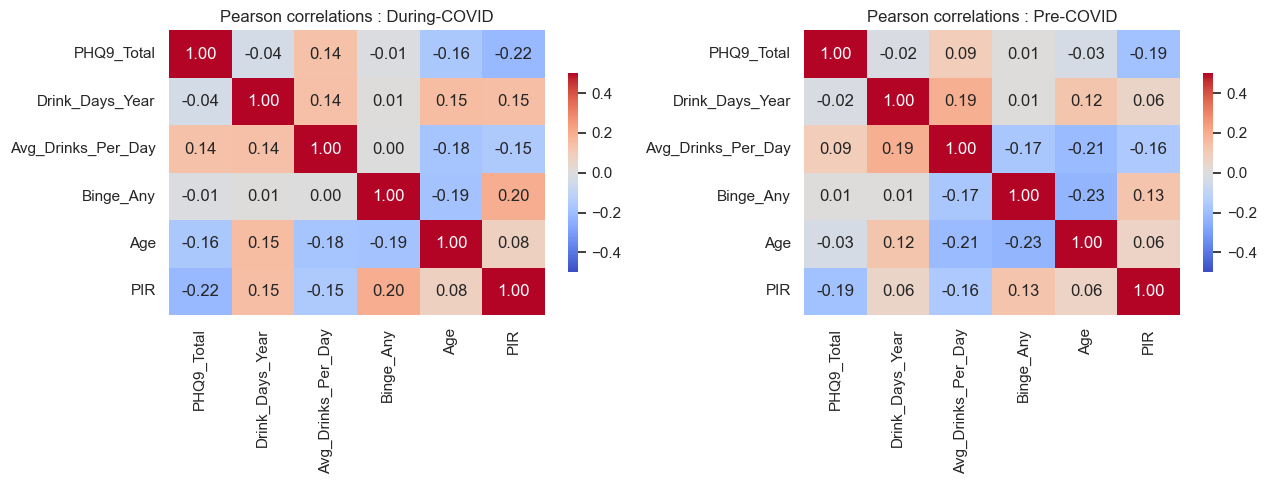

In [22]:
num_cols = ['PHQ9_Total', 'Drink_Days_Year', 'Avg_Drinks_Per_Day',
            'Binge_Any', 'Age', 'PIR']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (lbl, sub) in zip(axes, analytic.groupby('cycle_lbl')):
    corr = sub[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-0.5, vmax=0.5, ax=ax,
                cbar_kws={'shrink': 0.7})
    ax.set_title(f'Pearson correlations : {lbl}')
plt.tight_layout()
plt.show()


### 3.9 EDA takeaways

This section sets up the analysis notebook by:

- confirming we have a large analytic sample in both cycles (sample sizes shown in §3.1);
- showing that PHQ-9 is right-skewed in both cycles, with the bulk of respondents in the *Minimal* severity band;
- characterizing the distribution of alcohol-use frequency among drinkers, and the overall binge-drinking rates by cycle;
- providing a first descriptive view (§3.6) of how mean drinking days per year vary across depression severity bands in each cycle, the central pattern our modeling will formalize
- decomposing that bivariate pattern by age group and sex to flag where any cycle-level shift may be concentrated.

The formal tests of whether the depression–alcohol *relationship* changed between cycles via a multiple linear regression with a depression × cycle interaction, a General Linear Hypothesis F-test on that interaction, joint GLH tests on three-way interactions for subgroup heterogeneity, and a parallel logistic regression for binge drinking are carried out in the separate analysis notebook.
